In [1]:
# CELL 1: 
# This cell contains all the preliminary imports and settings to run the following cells
# You need to paste in your own token that you obtain from the ibmq account (specified in notes)
# You need to select your backend by commenting uncommenting the relevant lines as specified in the notes
# All the rest shouldn't be modified

import os 

# Input functions
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.circuit.library import RealAmplitudes
from qiskit.visualization import plot_histogram
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from qiskit.circuit import Parameter
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()  # take environment variables from .env.

backend_aer = AerSimulator()
fake_manila = FakeManilaV2()
 
# Save an IBM Quantum account and set it as your default account. You must input your own token, 
# which you can get from the dashboard on your IBMQ account
QiskitRuntimeService.save_account(
    channel="ibm_quantum",
    token=os.environ.get("ibmq_api_key"),
    set_as_default=True,
    # Use `overwrite=True` if you're updating your token.
    overwrite=True,
)
 
# Load saved credentials
service = QiskitRuntimeService()

# Choose your backend, you should always test your circuit on a simulator first.
# To select one remove the # symbol (uncomment) in front of the corresponding line, and make sure you 
# remove any indent
# Make sure that all the other backends are commented (add # symbol in front)
# default is using the Aer simulator

backend = backend_aer  
# backend = FakeManilaV2() 

# Choosing the following backend sends your job to the least busy quantum processor at IBMquantum.
# Make sure you note down which processor was used
# Make sure you do this only after your circuit has been fully tested.

# backend = service.least_busy(operational=True, simulator=False) 

# sets optimization level
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)


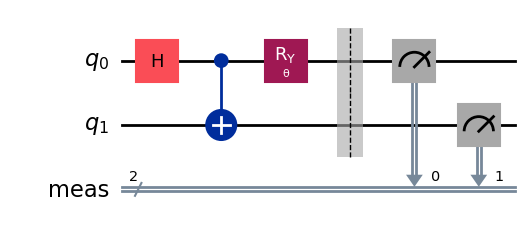

In [2]:
# CELL 2:
#CIRCUIT 1:
# In this cell we create a circuit to create your Bell state
# We introduce a parameter theta that will be helpful for your measurements.
# Parameter allows us to create a series of circuits for different e.g. rotation angles
# Each circuit will give an output that can be compiled into the results.


# We introduce a parameter to rotate one qubit through an angle θ.
theta = Parameter('θ')
# Define the circuit to allow the composition of the circuit.
# We need only 2 qubits and the "meas" classical register, 
# which is default so we don't need to specify. 
par_qc_ent = QuantumCircuit(2)

# You need to edit the following to make your circuit. 
# Add gates as new lines - see below for more gates.
# Remember the pay attention to the order of the commands.
# Remember to specify q: the qubit(s) you want the gate to act on
par_qc_ent.h(0) # X Pauli gate
par_qc_ent.cx(0,1) # CNOT gates. This one has 0 as control, 1 as target
par_qc_ent.ry(theta, 0) # rotation gate, Y axis; angle = theta, qubit is 0

# Other gates you may need:
# par_qc_ent.h(q) # Hadamard gate H(q) acts on qubit q; set q to 0 or 1. 
# par_qc_ent.x(q) # X Pauli gate acts on qubit q; set q to 0 or 1. 
# par_qc_ent.y(q) # Y Pauli gate acts on qubit q; set q to 0 or 1. 
# par_qc_ent.rx(-theta, q) # rotation gate, X axis through angle theta, on qubit q
# par_qc_ent.ry(-theta, q) # rotation gate, Y axis through angle theta, on qubit q
# par_qc_ent.rz(-theta, q) # rotation gate, Z axis through angle theta, on qubit q
# par_qc_ent.y(0) # Y Pauli gate 
# par_qc_ent.z(0) # Z Pauli gate 

# Take a measurement on both qubit 0 and qubit 1.
par_qc_ent.measure_all()

# Draw your circuit. Check it looks like the one you made in the composer.
par_qc_ent.draw('mpl')


In [3]:
# CELL 3:
# Sets up your parametric circuit for a range of theta and defines the number of shots
# This input will be then used to create PUBS (parametrised circuits) to be collated in one job.
# You need to choose a sensible number of steps,  a good range of angles and a sensible number of shots.

# First experiment has theta = 0, 
# theta = θ will take a number num_steps of values between start_theta and end_theta.
# You need to decide what these values should be and input them below
start_theta = 0;
end_theta = np.pi;
num_steps = 10; # you will need more than three points
# set the number of shots for each data point here. 
#The maximum possible is 8152,  but such a large number is a drain on resources.
num_shots = 1024;
# The next line makes a list of theta values for your parametrised circuits.
theta_vals = np.linspace(start_theta, end_theta, num_steps) # start_theta to end_theta  in num_steps steps
# print(theta_vals)

# Next we prepare our job. 
# The transpilation process converts your circuit to an equivalent and more efficient circuit.
# This process depends on the backend used
# The Sampler primitive is called to run the isa_circuit, for all the different theta and number of shots specified.
# This is sent just as one "job" using the Sampler Primitive and PUBs (Primitive unified block).  
# You retrieve all the results jointly.
isa_circuits =  transpile(par_qc_ent,backend)
sampler = Sampler(backend)
job = sampler.run([(isa_circuits, theta_vals, num_shots)])
result = job.result()

# JOB ID: you may need the job ID for later.
# It's printed below, or you can grab it from the 'jobs' filenames in the IBMq portal.
job.job_id()
# copy the job id somewhere safe, or paste it into line 6 in the cell below, 


'9d7ed166-8181-46c0-b50a-cd3248944714'

PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(10,), num_shots=1024, num_bits=2>), shape=(10,)), metadata={'shots': 1024, 'circuit_metadata': {}})], metadata={'version': 2})


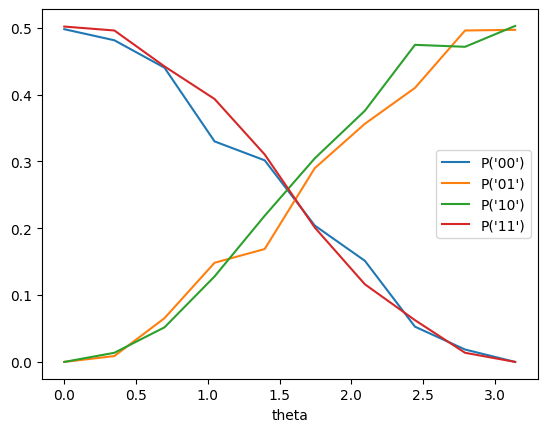

In [4]:
# CELL 4:
# Plots the results. this is useful to sense check the output
# You should use the raw data to plot/tabulate your own data 
# If you sent the job to a quantum processor and navigated away from the IBM site during your run, 
# you can retrieve the results here, by uncommenting the line below and pasting the job number.

# Paste job number given above into this cell.
#job = service.job('32318690-05da-4273-9974-505b956fdbe8')

print(result)
data_result = result[0].data
bits = data_result.meas
#print("array:\n", bits.array)

#Sum counts over number of shots
p00s = np.sum(bits.array == 0, axis=1) 
p01s = np.sum(bits.array == 1, axis=1) 
p10s = np.sum(bits.array == 2, axis=1) 
p11s = np.sum(bits.array == 3, axis=1) 


#Sum counts over number of shots and normalise to have a quasi-probability
p00s_array = np.sum(bits.array == 0, axis=1) / bits.num_shots
p01s_array = np.sum(bits.array == 1, axis=1) / bits.num_shots
p10s_array = np.sum(bits.array == 2, axis=1) / bits.num_shots
p11s_array = np.sum(bits.array == 3, axis=1) / bits.num_shots

# Plot your data
plt.plot(theta_vals, p00s_array, label="P('00')")
plt.plot(theta_vals, p01s_array,  label="P('01')")
plt.plot(theta_vals, p10s_array,  label="P('10')")
plt.plot(theta_vals, p11s_array,  label="P('11')")
plt.xlabel("theta")
plt.legend()
# Show the plot
plt.show()



In [5]:
# If you want to see the data arrays for '00','01','10','11', uncomment the line below
print("-------Theta--------")
print(theta_vals)
print("------------------")
print("------p00----------")
print(p00s_array)
print("------------------")
print("------p01----------")
print(p01s_array)
print("------------------")
print("------p10----------")
print(p10s_array)
print("------------------")
print("------p11----------")
print(p11s_array)

-------Theta--------
[0.         0.34906585 0.6981317  1.04719755 1.3962634  1.74532925
 2.0943951  2.44346095 2.7925268  3.14159265]
------------------
------p00----------
[[0.49804688]
 [0.48144531]
 [0.44042969]
 [0.33007812]
 [0.30175781]
 [0.20410156]
 [0.15136719]
 [0.05273438]
 [0.01855469]
 [0.        ]]
------------------
------p01----------
[[0.        ]
 [0.00878906]
 [0.06542969]
 [0.1484375 ]
 [0.16894531]
 [0.29003906]
 [0.35644531]
 [0.41015625]
 [0.49609375]
 [0.49707031]]
------------------
------p10----------
[[0.        ]
 [0.01367188]
 [0.05175781]
 [0.12792969]
 [0.21875   ]
 [0.3046875 ]
 [0.37597656]
 [0.47460938]
 [0.47167969]
 [0.50292969]]
------------------
------p11----------
[[0.50195312]
 [0.49609375]
 [0.44238281]
 [0.39355469]
 [0.31054688]
 [0.20117188]
 [0.11621094]
 [0.0625    ]
 [0.01367188]
 [0.        ]]


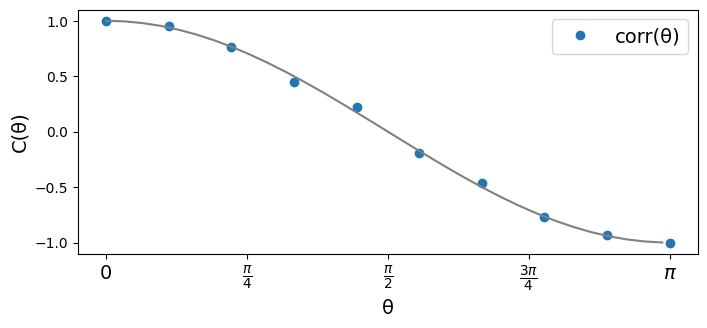

In [6]:
# CELL 5:
# Plot the correlation function

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)

# below the correlation function is calculated point by point.
# check the signs! 
# remember: correlation is (N(agree) - N(disagree))/N(total).
# outputs 00 and 11 agree, 10 and 01 disagree.
# check division by N(total).

corr = list(map(lambda a, b, c, d: (a + d -c -b)/bits.num_shots, p00s, p01s, p10s, p11s))

# make the plot and labels etc.
ax.plot(theta_vals, corr, 'o', label='corr(θ)')
ax.set_xticks([i * np.pi / 4 for i in range(5)])

# need to plot the theoretical correlation function too.
x_range = np.arange(start_theta, end_theta, 0.1)
cos_func= np.cos(x_range)
ax.plot(x_range, cos_func, color='grey')

# not essential: check the frame ticks are appropriate for your range. 
ax.set_xticklabels(['0', r'$\frac{\pi}{4}$', r'$\frac{\pi}{2}$', r'$\frac{3\pi}{4}$', r'$\pi$'], fontsize=14)
ax.set_xlabel('θ', fontsize=14)
ax.set_ylabel('C(θ)', fontsize=14)
ax.legend(fontsize=14);
plt.gca().set_aspect( 0.618034 )

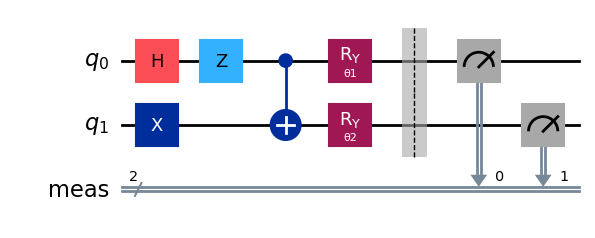

In [7]:
# CELL 6:
# CIRCUIT 2: gets data so you can calculate the CHSH sum. Therefore, you need to rotate one of the qubits.
# Hint: what angles are used to maximise the CHSH sum? Which ones did you already get above?
# You should see you need to rotate the qubit you did not rotate above. 
# We change the name of the circuit from par_qc_ent to par_qc_ent_2, just to avoid confusion.

# We introduce the parameter to rotate one of the qubits through an angle θ.
theta1 = Parameter('θ1')
theta2 = Parameter('θ2')
theta12_vals = np.array([theta_vals,theta_vals[::-1]]).T
# Define the circuit to allow the composition of the circuit. We need only 2 qubits and the "meas" classical register, 
# which is default so we don't need to specify. 
par_qc_ent_2 = QuantumCircuit(2)

# You need to edit the following to make your circuit. 
# Add gates as new lines - see below for more gates: remember the pay attention to the order of the commands and 
# to specify q: the qubit(s) you want the gate to act on
par_qc_ent_2.h(0) # Hadamard gate H(q) acts on qubit q;
par_qc_ent_2.x(1) # X Pauli gate
par_qc_ent_2.z(0) # Z Pauli gate 
par_qc_ent_2.cx(0,1) # CNOT gates. This one has 0 as control, 1 as target
par_qc_ent_2.ry(theta1, 0) # rotation gate, Y axis; angle = theta, qubit is 0
par_qc_ent_2.ry(theta2, 1) # rotation gate, Y axis; angle = theta, qubit is 0

# Take a measurement on both qubit 0 and qubit 1.
par_qc_ent_2.measure_all()

# Other gates you may need:
# par_qc_ent_2.h(q) # Hadamard gate H(q) acts on qubit q; set q to 0 or 1. 
# par_qc_ent_2.x(q) # X Pauli gate acts on qubit q; set q to 0 or 1. 
# par_qc_ent_2.y(q) # Y Pauli gate acts on qubit q; set q to 0 or 1. 
# par_qc_ent_2.rx(-theta, q) # rotation gate, X axis through angle theta, on qubit q
# par_qc_ent_2.ry(-theta, q) # rotation gate, Y axis through angle theta, on qubit q
# par_qc_ent_2.rz(-theta, q) # rotation gate, Z axis through angle theta, on qubit q
# par_qc_ent_2.y(0) # Y Pauli gate 
# par_qc_ent_2.z(0) # Z Pauli gate 

# Draw your circuit. Check it looks like the one you made in the composer.
par_qc_ent_2.draw('mpl')
# print(theta12_vals)

In [8]:
# CELL 7:
# Next we prepare our job. The transpilation process converts your circuit to an equivalent and more efficient circuit depending on the backend used
# we then instruct the Sampler primitive to run the isa_circuit, for all the different theta (defined in CELL 3) and for the number of shots specified.
# This is sent just as one "job" using the Sampler Primitive and PUBs (Primitive unified block).  You retrieve all the results jointly.
isa_circuits_2 =  transpile(par_qc_ent_2,backend)
sampler = Sampler(backend)
job_2 = sampler.run([(isa_circuits_2, theta12_vals, num_shots)])
result_2 = job_2.result()

# JOB ID: you may need the job ID for later.
#It's printed below, or you can grab it from the 'jobs' filenames
job_2.job_id()
# copy the job id somewhere safe, or paste it into line 6 in the cell below, 


'faa0f7e0-02ba-42e1-be4b-4cee8edb4239'

[-3.14159265 -2.44346095 -1.74532925 -1.04719755 -0.34906585  0.34906585
  1.04719755  1.74532925  2.44346095  3.14159265]
[ 1.          0.78125     0.17382812 -0.49804688 -0.953125   -0.93945312
 -0.50195312  0.19335938  0.77539062  1.        ]
corr uncertainty 0.03125


ValueError: 'yerr' (shape: (10, 1)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (10, 1))

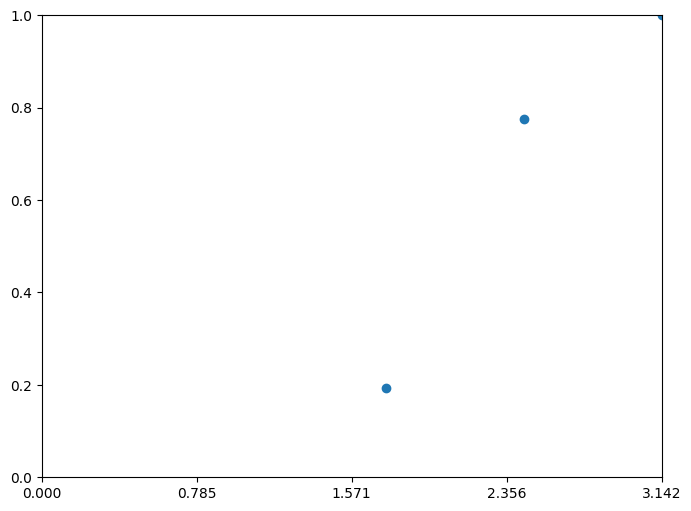

In [ ]:
# CELL 8:
# plots the results. this is useful to sense check the output
# you should use the raw data to plot/tabulate your own data 

# If navigated away from the IBM site during your run, you can retrieve the results here.
# Paste job number given above into this cell.
#job = service.job('32318690-05da-4273-9974-505b956fdbe8')

data_result_2 = result_2[0].data
bits_2 = data_result_2.meas
#print("array:\n", bits.array)


#sum counts over number of shots
p00s_2 = np.sum(bits_2.array == 0, axis=1) 
p01s_2 = np.sum(bits_2.array == 1, axis=1) 
p10s_2 = np.sum(bits_2.array == 2, axis=1) 
p11s_2 = np.sum(bits_2.array == 3, axis=1) 

# Plot the correlation function

import matplotlib.pyplot as plt
# plt.rcParams['text.usetex'] = True
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)

# below the correlation function is calculated point by point.
# check the signs! 
# remember: correlation is (N(agree) - N(disagree))/N(total).
# outputs 00 and 11 agree, 10 and 01 disagree.
# check division by N(total).
corr_2 = list(map(lambda a2, b2, c2, d2: (a2 + d2 -c2 -b2)/bits.num_shots, p00s_2, p01s_2, p10s_2, p11s_2))
corr_uncertainty = 1/np.sqrt(bits.num_shots)
yerr = np.full_like(corr_2, corr_uncertainty)

x=theta_vals - theta_vals[::-1]
print(x)

corr_2_flat = np.array([corr[0] for corr in corr_2])
print(corr_2_flat)
print(f"corr uncertainty {corr_uncertainty}")

# make the plot and labels etc.
# ax.plot(theta_vals-theta_vals[::-1], corr_2, 'o', label='D(θ_1, θ_2)')
ax.set_xticks([i * np.pi / 4 for i in range(5)])
ax.errorbar(x, corr_2, yerr=corr_uncertainty, fmt='o', label='D(θ_1, θ_2)', capsize=5)
# ax.errorbar(theta_vals - theta_vals[::-1], corr_2, yerr=corr_uncertainty, fmt='o', label='D(θ_1, θ_2)', capsize=5)


# need to plot the theoretical correlation function too.
x0_range = np.arange(start_theta, end_theta, 0.1)
x1_range = np.arange(end_theta,start_theta, -0.1)
cos_func= -np.cos(x0_range-x1_range)
ax.plot(x0_range-x1_range, cos_func, color='grey', label='C(θ_1, θ_2)')

# not essential: check the frame ticks are appropriate for your range. 
ax.set_xticklabels(['0', r'$\frac{\pi}{4}$', r'$\frac{\pi}{2}$', r'$\frac{3\pi}{4}$', r'$\pi$'], fontsize=14)
ax.set_xlabel('θ_1-θ_2', fontsize=14)
# ax.set_ylabel('C(θ_1, θ_2)', fontsize=14)
ax.legend(fontsize=14);
plt.gca().set_aspect( 0.999 )
